<a href="https://colab.research.google.com/github/Raksh1707/Naturalproject/blob/main/nlp8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import string
import nltk
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter

from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer

# Download required NLTK data
nltk.download('stopwords')
nltk.download('vader_lexicon')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [3]:
feedback = [

    "The product quality is excellent and worth the price.",
    "Packaging was damaged when I received the product.",
    "Very satisfied with the overall performance.",
    "The battery life should be improved.",
    "Affordable price and good quality.",
    "Customer support was very helpful.",
    "The product stopped working after one week.",
    "Excellent packaging and fast delivery.",
    "The instructions are confusing.",
    "I love the attractive design.",
    "Poor build quality and weak material.",
    "The product is easy to use.",
    "Delivery was delayed by several days.",
    "Very happy with this purchase.",
    "The price is slightly expensive.",
    "Amazing performance and smooth operation.",
    "The packaging looks premium.",
    "The app crashes frequently.",
    "Battery backup is excellent.",
    "I will definitely recommend this product.",
    "The product is not worth the money.",
    "Very comfortable and user friendly.",
    "The camera quality is impressive.",
    "The warranty process is slow.",
    "Excellent value for money.",
    "Product quality exceeded my expectations.",
    "The screen brightness is very good.",
    "Customer service needs improvement.",
    "Overall I am satisfied with the purchase.",
    "The product arrived with missing accessories."

]

df = pd.DataFrame({
    "Feedback": feedback
})
print("First Five Feedback Records")
print(df.head())

First Five Feedback Records
                                            Feedback
0  The product quality is excellent and worth the...
1  Packaging was damaged when I received the prod...
2       Very satisfied with the overall performance.
3               The battery life should be improved.
4                 Affordable price and good quality.


In [4]:
stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = text.lower()

    text = text.translate(str.maketrans("", "", string.punctuation))

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["Clean_Feedback"] = df["Feedback"].apply(clean_text)

print("\nCleaned Feedback")
print(df[["Feedback","Clean_Feedback"]].head())



Cleaned Feedback
                                            Feedback  \
0  The product quality is excellent and worth the...   
1  Packaging was damaged when I received the prod...   
2       Very satisfied with the overall performance.   
3               The battery life should be improved.   
4                 Affordable price and good quality.   

                          Clean_Feedback  
0  product quality excellent worth price  
1     packaging damaged received product  
2          satisfied overall performance  
3                  battery life improved  
4          affordable price good quality  


In [5]:
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):

    score = sia.polarity_scores(text)["compound"]

    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Feedback"].apply(get_sentiment)

print("\nSentiment Analysis")
print(df[["Feedback","Sentiment"]])



Sentiment Analysis
                                             Feedback Sentiment
0   The product quality is excellent and worth the...  Positive
1   Packaging was damaged when I received the prod...  Negative
2        Very satisfied with the overall performance.  Positive
3                The battery life should be improved.  Positive
4                  Affordable price and good quality.  Positive
5                  Customer support was very helpful.  Positive
6         The product stopped working after one week.  Negative
7              Excellent packaging and fast delivery.  Positive
8                     The instructions are confusing.  Negative
9                       I love the attractive design.  Positive
10              Poor build quality and weak material.  Negative
11                        The product is easy to use.  Positive
12              Delivery was delayed by several days.  Negative
13                     Very happy with this purchase.  Positive
14                  

In [6]:
keywords = [
    "battery",
    "packaging",
    "delivery",
    "quality",
    "price",
    "support",
    "service",
    "camera",
    "screen",
    "warranty",
    "design",
    "instructions",
    "accessories",
    "app"
]

all_words = " ".join(df["Clean_Feedback"]).split()

issues = [word for word in all_words if word in keywords]

issue_count = Counter(issues)

print("\nProduct Improvement Areas")

for word, count in issue_count.items():
    print(word, ":", count)



Product Improvement Areas
quality : 5
price : 3
packaging : 3
battery : 2
support : 1
delivery : 2
instructions : 1
design : 1
app : 1
camera : 1
warranty : 1
screen : 1
service : 1
accessories : 1


In [7]:
print("\nBusiness Insights")
print("-------------------------")

print(df["Sentiment"].value_counts())

print("\nTop Improvement Areas")

for word, count in issue_count.most_common(5):
    print(word, "-", count)



Business Insights
-------------------------
Sentiment
Positive    18
Negative     7
Neutral      5
Name: count, dtype: int64

Top Improvement Areas
quality - 5
price - 3
packaging - 3
battery - 2
delivery - 2


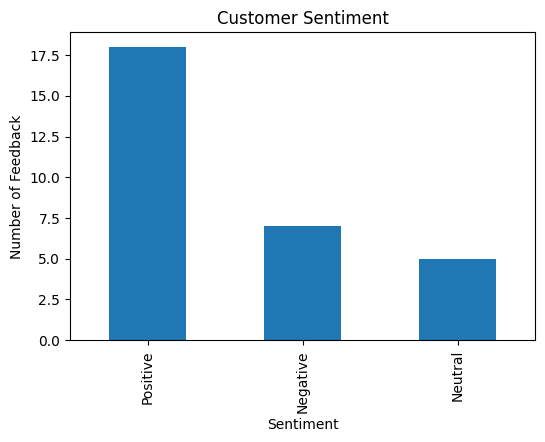

In [8]:
plt.figure(figsize=(6,4))

df["Sentiment"].value_counts().plot(kind="bar")

plt.title("Customer Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Feedback")

plt.show()


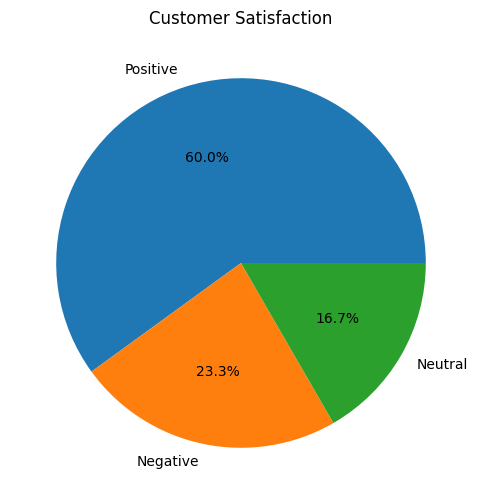

In [9]:
plt.figure(figsize=(6,6))

df["Sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Customer Satisfaction")

plt.show()

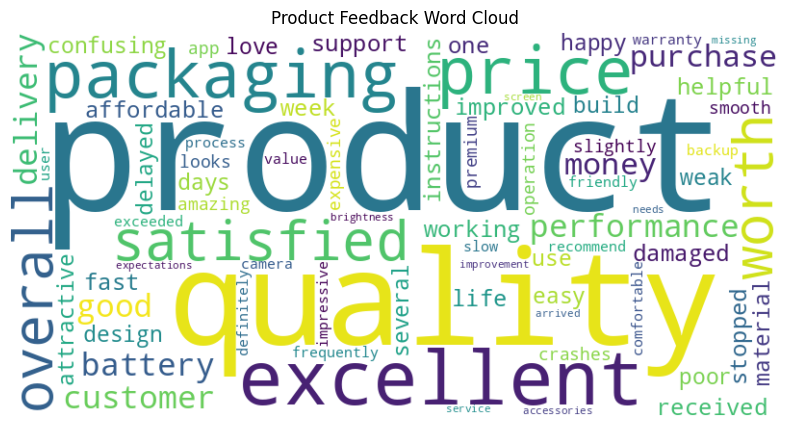

In [10]:
text = " ".join(df["Clean_Feedback"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")

plt.title("Product Feedback Word Cloud")

plt.show()

In [11]:
df.to_csv("Product_Feedback_Analysis_Output.csv", index=False)

print("\nAnalysis Completed Successfully!")
print("Output saved as Product_Feedback_Analysis_Output.csv")


Analysis Completed Successfully!
Output saved as Product_Feedback_Analysis_Output.csv
